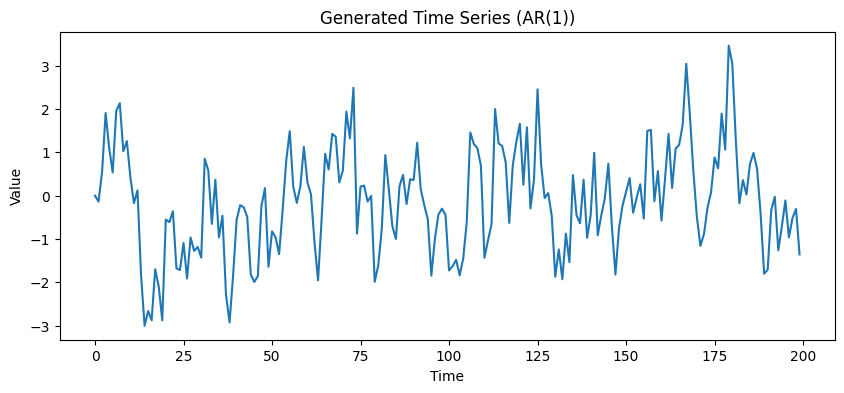

In [18]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200
noise = np.random.normal(0, 1, n)

y = np.zeros(n)

for t in range(1, n):
    y[t] = 0.7 * y[t-1] + noise[t]

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Generated Time Series (AR(1))")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

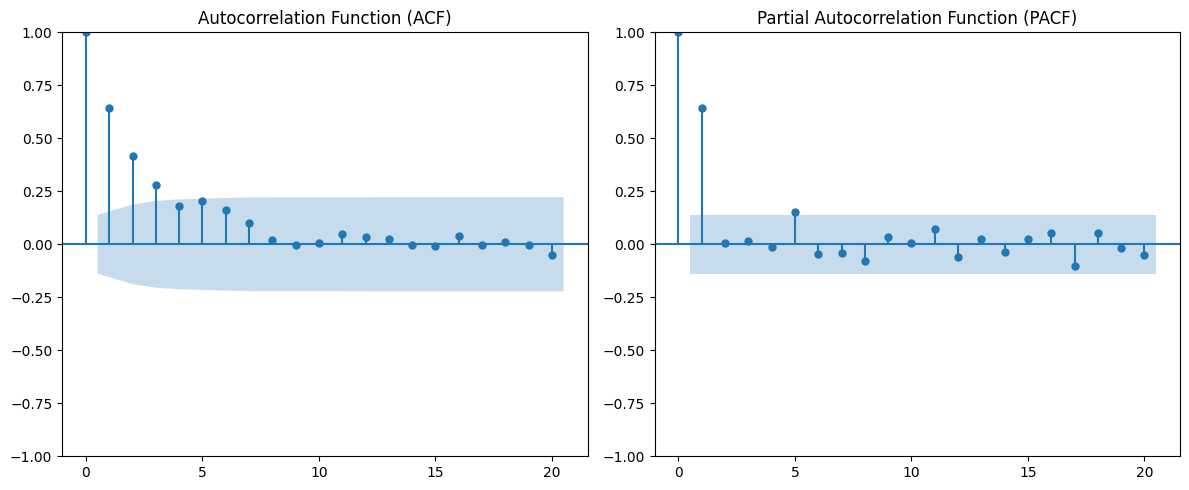

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

plt.subplot(121)
plot_acf(y, lags=20, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

plt.subplot(122)
plot_pacf(y, lags=20, ax=plt.gca())
plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [20]:
def autocorrelation(series, lag):
    
    n = len(series)
    mean = np.mean(series)
    
    numerator = 0
    denominator = 0
    
    for t in range(lag, n):
        numerator += (series[t] - mean) * (series[t-lag] - mean)
    
    for t in range(n):
        denominator += (series[t] - mean)**2
        
    return numerator / denominator

In [21]:
acf_values = [autocorrelation(y, lag) for lag in range(1, 21)]

print(acf_values)

[0.6441519585164864, 0.4187551215739293, 0.28069670220399395, 0.17912247981511514, 0.20448812185827558, 0.16276026579316052, 0.10080112114667907, 0.02248455567099018, -0.003390367442999716, 0.0038005580585241464, 0.05008165743436808, 0.03558509952971273, 0.025057326963736498, -0.0038776999766095095, -0.009903008224516209, 0.04066809151190161, -0.005187666909331124, 0.011055056913427156, -0.003190172901096313, -0.04895112944957288]


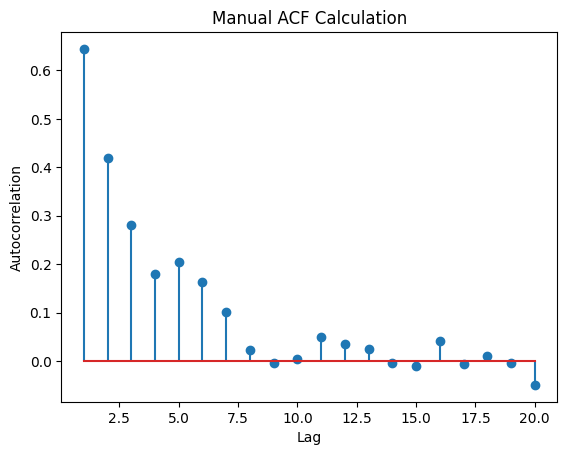

In [22]:
plt.stem(range(1,21), acf_values)
plt.title("Manual ACF Calculation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

In [23]:
import statsmodels.api as sm

def pacf_lag(series, lag):

    y = series[lag:]
    
    X = []
    
    for i in range(1, lag+1):
        X.append(series[lag-i:-i])
        
    X = np.column_stack(X)
    
    model = sm.OLS(y, sm.add_constant(X)).fit()
    
    return model.params[-1]

In [24]:
pacf_values = [pacf_lag(y, lag) for lag in range(1,10)]

print(pacf_values)

[0.6474954204923067, 0.003708592230336701, 0.016331678607201538, -0.011471525703545309, 0.15404141577708666, -0.044447252695249725, -0.03623609957407257, -0.07695992332580474, 0.03723481944249522]


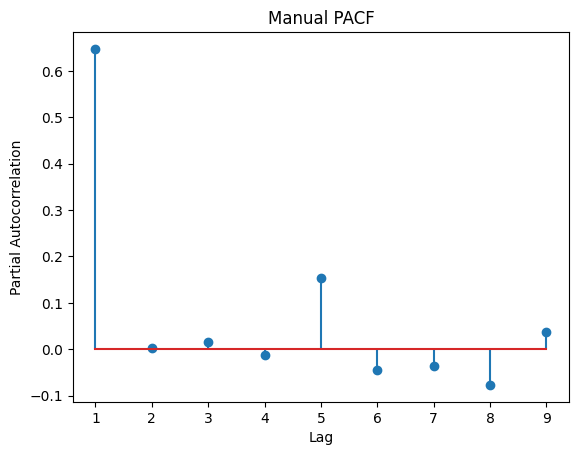

In [25]:
plt.stem(range(1,10), pacf_values)
plt.title("Manual PACF")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

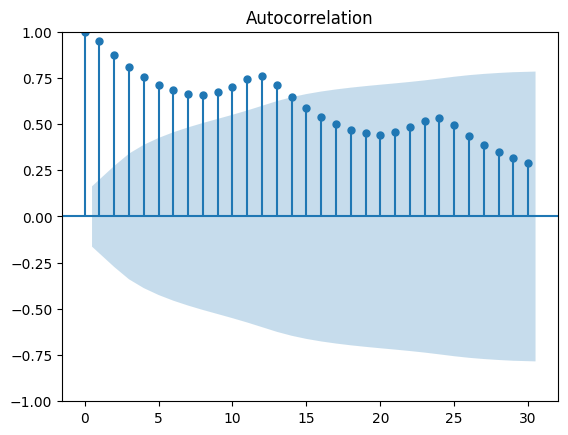

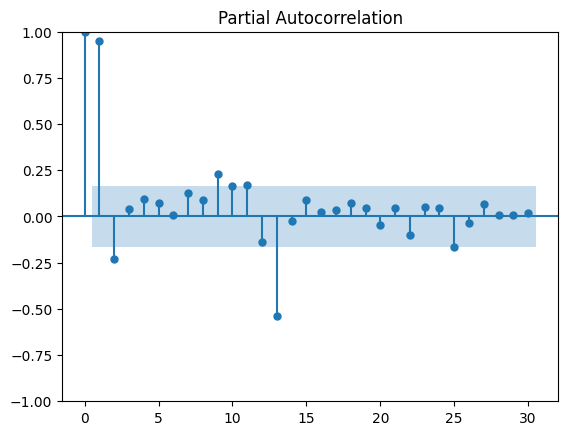

In [26]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

data = pd.read_csv(url)

series = data['Passengers']

plot_acf(series, lags=30)
plt.show()

plot_pacf(series, lags=30)
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n = 100
noise = np.random.normal(0,1,n)

series = np.zeros(n)

for t in range(1,n):
    series[t] = 0.8*series[t-1] + noise[t]

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n = 100
noise = np.random.normal(0,1,n)

series = np.zeros(n)

for t in range(1,n):
    series[t] = 0.8*series[t-1] + noise[t]

In [29]:
def autocorr(x, lag):
    
    mean = np.mean(x)
    
    numerator = np.sum((x[lag:] - mean)*(x[:-lag] - mean))
    denominator = np.sum((x - mean)**2)
    
    return numerator/denominator

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


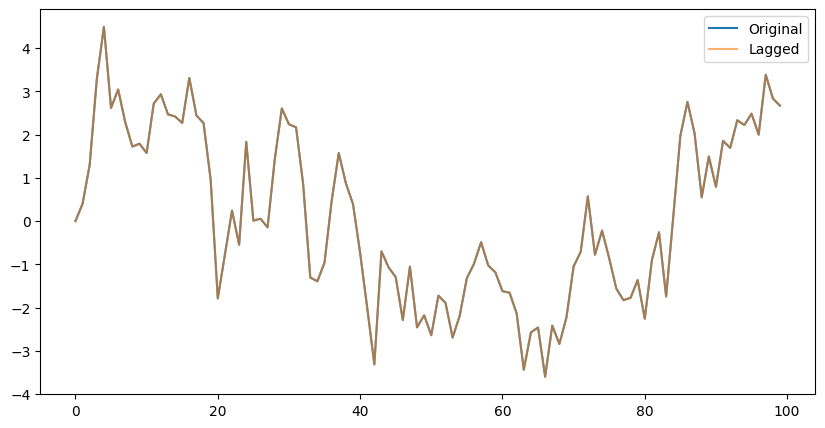

In [31]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(10,5))

line1, = ax.plot(series, label="Original")
line2, = ax.plot(series, alpha=0.6, label="Lagged")

text = ax.text(0.02,0.9,"", transform=ax.transAxes)

ax.legend()

def update(frame):
    
    lag = frame
    
    lagged = np.roll(series, lag)
    
    line2.set_ydata(lagged)
    
    if lag > 0:
        corr = autocorr(series, lag)
        text.set_text(f"Lag = {lag}   ACF = {corr:.3f}")
    
    return line2, text

ani = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=800
)

plt.show()

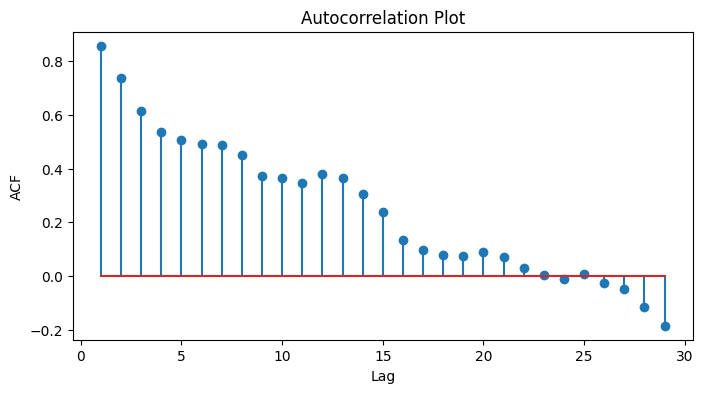

In [ ]:
lags = 30
acf_vals = [autocorr(series, lag) for lag in range(1,lags)]

plt.figure(figsize=(8,4))
plt.stem(range(1,lags), acf_vals)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("Autocorrelation Plot")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_8136\2992349461.py:31: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  ).fit(


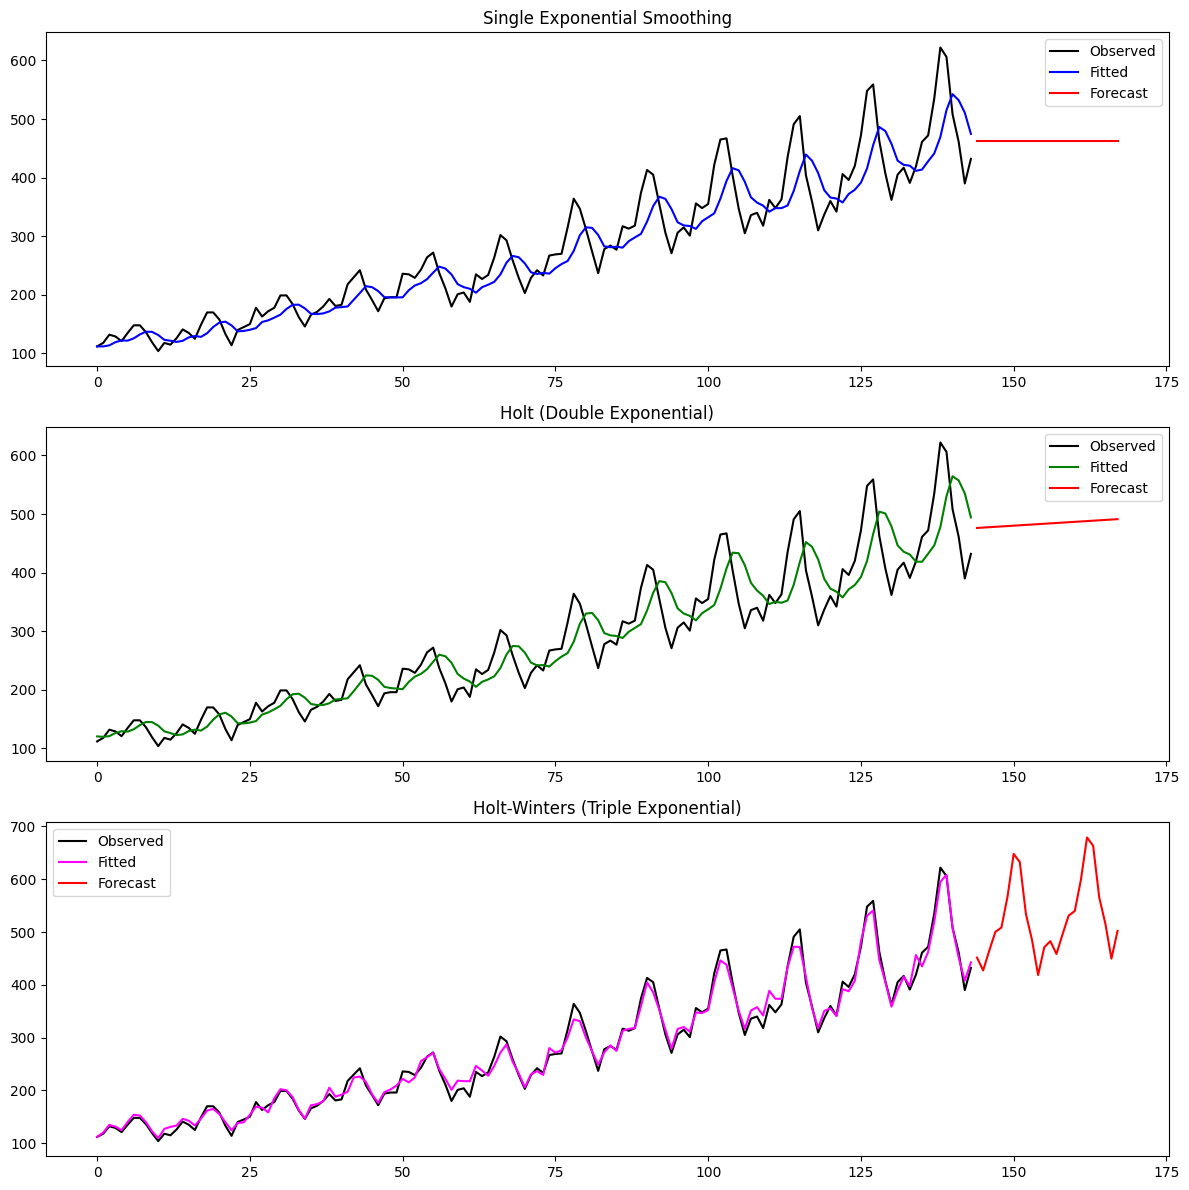

In [35]:
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# airline passengers data
series_hw = data['Passengers']

# number of steps to forecast
forecast_steps = 24   # forecast next 24 months

# -----------------------------
# 1) Single Exponential Smoothing
# -----------------------------
alpha = 0.3

ses_model = SimpleExpSmoothing(series_hw).fit(
    smoothing_level=alpha,
    optimized=False
)

ses_fit = ses_model.fittedvalues
ses_forecast = ses_model.forecast(forecast_steps)


# -----------------------------
# 2) Holt (Double Exponential)
# -----------------------------
holt_model = ExponentialSmoothing(
    series_hw,
    trend='add',
    seasonal=None
).fit(
    smoothing_level=alpha,
    smoothing_slope=0.1,
    optimized=False
)

holt_fit = holt_model.fittedvalues
holt_forecast = holt_model.forecast(forecast_steps)


# -----------------------------
# 3) Holt-Winters (Triple)
# -----------------------------
hw_model = ExponentialSmoothing(
    series_hw,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_fit = hw_model.fittedvalues
hw_forecast = hw_model.forecast(forecast_steps)


# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(12,12))

# SES
plt.subplot(311)
plt.plot(series_hw, label="Observed", color="black")
plt.plot(ses_fit, label="Fitted", color="blue")
plt.plot(ses_forecast, label="Forecast", color="red")
plt.title("Single Exponential Smoothing")
plt.legend()


# Holt
plt.subplot(312)
plt.plot(series_hw, label="Observed", color="black")
plt.plot(holt_fit, label="Fitted", color="green")
plt.plot(holt_forecast, label="Forecast", color="red")
plt.title("Holt (Double Exponential)")
plt.legend()


# Holt-Winters
plt.subplot(313)
plt.plot(series_hw, label="Observed", color="black")
plt.plot(hw_fit, label="Fitted", color="magenta")
plt.plot(hw_forecast, label="Forecast", color="red")
plt.title("Holt-Winters (Triple Exponential)")
plt.legend()

plt.tight_layout()
plt.show()